### Corelation using Pearson and Spearman Rank

- H₀: ρ = 0 (No correlation between Intentional Death and Economic Gini Index of a country)
- H₁: ρ ≠ 0 (There is a correlation between Intentional Death and Economic Gini Index of a country)

In [2]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

dataset_path = "../data/merged_dataset.csv"

df = pd.read_csv(dataset_path)

df

#print(df['intentional_death'].max())
#print(df['intentional_death'].min())

,country_name,country_code,year,suicide_data,homicide_data,intentional_death,gini_index
0,albania,alb,2002,4.48,216.0,220.48,0.32
1,albania,alb,2005,6.91,154.0,160.91,0.31
2,albania,alb,2008,6.95,93.0,99.95,0.30
3,albania,alb,2012,4.09,157.0,161.09,0.29
4,albania,alb,2014,3.80,134.0,137.80,0.35
...,...,...,...,...,...,...,...
1227,vietnam,vnm,2008,7.29,1092.0,1099.29,0.36
1228,vietnam,vnm,2010,7.52,1336.0,1343.52,0.39
1229,zambia,zmb,2010,12.14,814.0,826.14,0.52
1230,zambia,zmb,2015,10.96,853.0,863.96,0.56


In [3]:
filtered_df = df[(df['intentional_death'] <= 10000)]

filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1120 entries, 0 to 1231
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country_name       1120 non-null   object 
 1   country_code       1120 non-null   object 
 2   year               1120 non-null   int64  
 3   suicide_data       1120 non-null   float64
 4   homicide_data      1120 non-null   float64
 5   intentional_death  1120 non-null   float64
 6   gini_index         1120 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 70.0+ KB


### Pearson Correlation

In [4]:
from scipy.stats import pearsonr
import numpy as np


correlation_matrix = filtered_df.corr(numeric_only=True)
print(correlation_matrix)

# Calculate correlation coefficient and p-value
corr_coefficient, p_value = pearsonr(filtered_df['intentional_death'], filtered_df['gini_index'])
print(f"Pearson Correlation Coefficient: {corr_coefficient}")
print(f"P-value: {p_value}")

                       year  suicide_data  homicide_data  intentional_death  \
year               1.000000     -0.090265      -0.129789          -0.130217   
suicide_data      -0.090265      1.000000      -0.118258          -0.114250   
homicide_data     -0.129789     -0.118258       1.000000           0.999992   
intentional_death -0.130217     -0.114250       0.999992           1.000000   
gini_index        -0.158476     -0.305286       0.349798           0.348723   

                   gini_index  
year                -0.158476  
suicide_data        -0.305286  
homicide_data        0.349798  
intentional_death    0.348723  
gini_index           1.000000  
Pearson Correlation Coefficient: 0.3487231218853638
P-value: 2.2606580155201972e-33


### Spearman Corelation

Spearman’s rank correlation is appropriate because:

a) Variables are continuous but highly skewed
- Intentional death ranges from 5.41 to 63,794.47, which shows extreme skewness and large outliers.
- Gini index ranges from 0.23 to 0.65, but is not normally distributed across countries.
- Spearman does not require normality, unlike Pearson.

b) The relationship may not be linear
- Spearman detects monotonic relationships, not just linear ones.
- This is ideal because: As inequality increases, intentional deaths may increase or decrease in a curved pattern, not necessarily in a straight line.
- Many cross-country social indicators behave non-linearly.

c) Spearman handles ranking better than raw values
- Because intentional death values vary by a factor of 10,000+, Spearman avoids the distortion that would occur if raw numeric magnitudes were used.
- It converts all values into ranks, making the test robust against:
    - non-normality
    - skewness
    - extreme values
    - heteroscedasticity

This makes it statistically safer for your dataset.

Spearman directly evaluates:

Whether the relative ordering (rank) of countries by inequality is associated with the ordering of countries by death rates.
In other words, it answers:
- Do countries with higher inequality tend to have higher intentional death rates, regardless of the exact numeric size?
- Is the relationship statistically significant (p-value)?
- Is the relationship positive or negative (sign of ρ)?


Below are the alternatives and why they were not ideal:

Alternative 1: Pearson Correlation

Rejected because:
- Pearson requires normally distributed variables → not true for intentional death.
- Pearson assumes a linear relationship → unlikely in socioeconomic data.
- Pearson is highly sensitive to outliers, and death data has extreme values.

Thus, Pearson would give misleading or unstable results.

Alternative 2: Kendall’s Tau

Considered, but less suitable because:
- Kendall is more conservative and gives lower coefficients.
- It is ideal for small datasets, not large cross-country panel datasets.
- Spearman is more commonly used in global development and socioeconomic datasets.

You could use it, but it offers no practical advantage here.


In [5]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute Spearman correlation
spearman_corr = numeric_df.corr(method='spearman')
print("Spearman Correlation Matrix:")
print(spearman_corr)


Spearman Correlation Matrix:
                       year  suicide_data  homicide_data  intentional_death  \
year               1.000000     -0.040138      -0.176784          -0.179340   
suicide_data      -0.040138      1.000000      -0.100793          -0.082442   
homicide_data     -0.176784     -0.100793       1.000000           0.999550   
intentional_death -0.179340     -0.082442       0.999550           1.000000   
gini_index        -0.120338     -0.377827       0.545895           0.541484   

                   gini_index  
year                -0.120338  
suicide_data        -0.377827  
homicide_data        0.545895  
intentional_death    0.541484  
gini_index           1.000000  


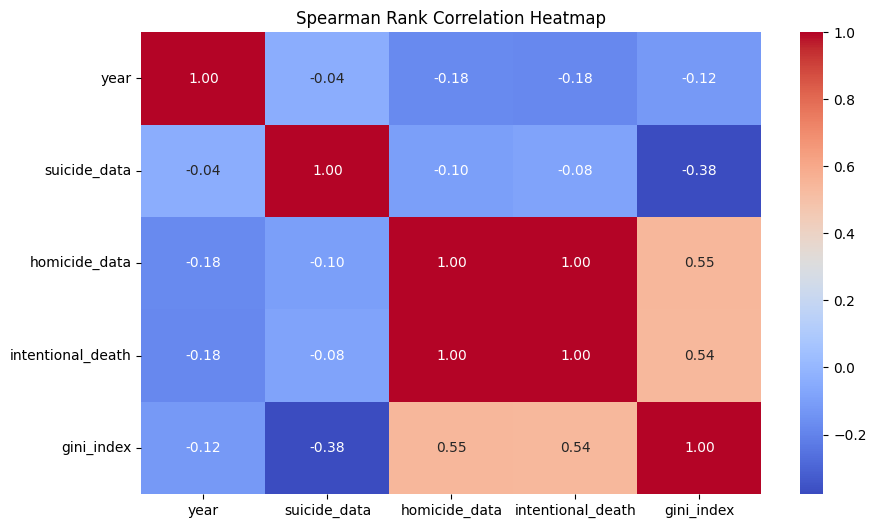

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Spearman Rank Correlation Heatmap")
plt.show()


In [7]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(df['intentional_death'], df['gini_index'])
print("Spearman correlation:", rho)
print("p-value:", p_value)


Spearman correlation: 0.5414843220331865
p-value: 8.666594075959332e-95


### Interpretation (APA Style)

A Spearman rank-order correlation showed a moderate positive association between economic inequality and intentional deaths,
ρ = 0.541, p < .001 (p-value: 8.66 × 10⁻⁹⁵).

Because the p-value is extremely small, we reject the null hypothesis.
There is statistically significant evidence that higher inequality is associated with higher intentional death rates.

In [8]:
import statsmodels.api as sm

X = filtered_df['gini_index']
y = filtered_df['intentional_death']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      intentional_death   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     154.8
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           2.26e-33
Time:                        19:51:00   Log-Likelihood:                -9732.5
No. Observations:                1120   AIC:                         1.947e+04
Df Residuals:                    1118   BIC:                         1.948e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1654.1678    204.019     -8.108      0.0

In [9]:
X = df[['gini_index', 'suicide_data', 'homicide_data', 'year']]
y = df['intentional_death']

X = sm.add_constant(X)
multi_model = sm.OLS(y, X).fit()
print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:      intentional_death   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 9.715e+31
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:51:00   Log-Likelihood:                 28940.
No. Observations:                1232   AIC:                        -5.787e+04
Df Residuals:                    1227   BIC:                        -5.784e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -7.276e-12   1.53e-10     -0.047

## Linear Regression

In [10]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ----------------------------
# Simple Linear Regression
# ----------------------------
model_simple = smf.ols("intentional_death ~ gini_index", data=df).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:      intentional_death   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     224.3
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           1.04e-46
Time:                        19:51:00   Log-Likelihood:                -12800.
No. Observations:                1232   AIC:                         2.560e+04
Df Residuals:                    1230   BIC:                         2.561e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.172e+04   1011.701    -11.582      0.0

## Multiple Regression

In [11]:
# ----------------------------
# Multiple Regression
# ----------------------------
model_multi = smf.ols("intentional_death ~ gini_index + suicide_data + homicide_data", data=df).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:      intentional_death   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.654e+30
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:51:00   Log-Likelihood:                 27111.
No. Observations:                1232   AIC:                        -5.421e+04
Df Residuals:                    1228   BIC:                        -5.419e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -8.242e-12   1.09e-11     -0.758

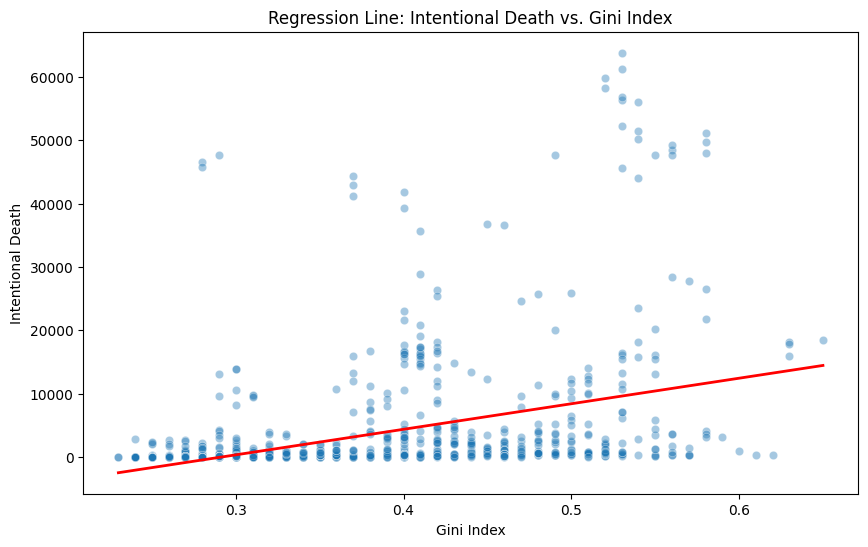

In [12]:
# Scatter + regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["gini_index"], y=df["intentional_death"], alpha=0.4)

# Regression line
x_vals = np.linspace(df["gini_index"].min(), df["gini_index"].max(), 100)
y_vals = model_simple.params["Intercept"] + model_simple.params["gini_index"] * x_vals

plt.plot(x_vals, y_vals, color="red", linewidth=2)
plt.title("Regression Line: Intentional Death vs. Gini Index")
plt.xlabel("Gini Index")
plt.ylabel("Intentional Death")
plt.show()

Random Forest Performance:
MAE : 54.7135664935077
RMSE: 250.16102780317092
R²  : 0.9991001757314084


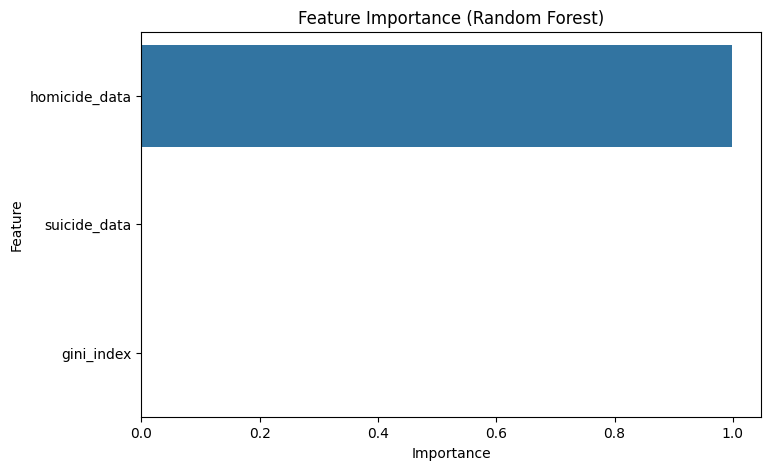

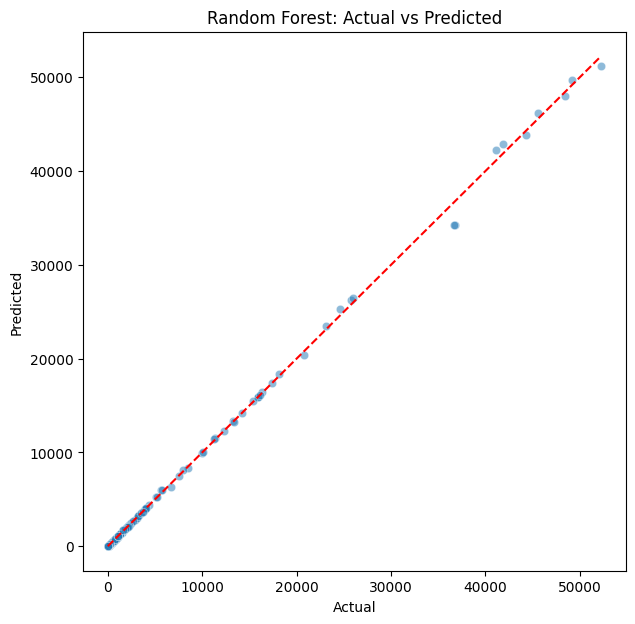

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Select Feature Variables
# -------------------------------
features = ["gini_index", "suicide_data", "homicide_data"]
X = df[features]
y = df["intentional_death"]

# -------------------------------
# 2. Split Data
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# -------------------------------
# 3. Train Random Forest Regressor
# -------------------------------
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# -------------------------------
# 4. Predictions
# -------------------------------
y_pred = rf.predict(X_test)

# -------------------------------
# 5. Evaluation Metrics
# -------------------------------
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("Random Forest Performance:")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

# -------------------------------
# 6. Feature Importance Plot
# -------------------------------
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Feature Importance (Random Forest)")
plt.show()

# -------------------------------
# 7. Predicted vs Actual Plot
# -------------------------------
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--', color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.show()